# 📘 Comprehensive Exploratory Data Analysis (EDA) Pipeline

**Objective:** This notebook provides a rigorous framework for "First Look" analysis, data cleaning, and relationship discovery. 

### Why do we do this?
EDA is critical for:
1.   **Detection of mistakes** (e.g., data entry errors, outliers).
2.   **Checking of assumptions** (e.g., Is the data Normal? Is the variance equal?).
3.   **Preliminary selection of models** (determining which algorithms fit the data shape).
4.   **Determining relationships** among explanatory and outcome variables.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

## 1. Data Loading and Structure Check

**Theory:**
Data is generally collected in a "rectangular array" with one row per subject and one column per variable.  Humans are poor at scanning raw spreadsheets, so we use programmatic inspection to understand the "Sample Distribution".

**What to look for:**
* **Data Types:** Are categorical variables stored as objects? Are numbers stored as numeric?
* **Shape:** Row count (n) vs. Column count (p).

In [8]:
def load_and_inspect(filepath=r'D:\Final Projects\AI Project\Data-set\bodyPerformance.csv', file_type='csv'):
    """
    Loads dataset and performs initial structural inspection.
    """
    try:
        if file_type == 'csv':
            df = pd.read_csv(filepath)
        elif file_type == 'excel':
            df = pd.read_excel(filepath)
        
        print(f"Data Loaded: {df.shape[0]} Rows, {df.shape[1]} Columns")
        print(df.info())
        
        display(df.head())
        
        return df
    except Exception as e:
        print(f"Error loading data: {e}")
        return None

In [7]:
df = pd.read_csv(r'D:\Final Projects\AI Project\Data-set\bodyPerformance.csv')
df.head()

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,M,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C
1,25.0,M,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A
2,31.0,M,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C
3,32.0,M,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,B
4,28.0,M,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,B


## Taking copy not to load the data again

In [9]:
df2 = df.copy()

## To Display all the columns

In [10]:
pd.set_option('display.max_columns', None)
display(df2.head())

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,M,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C
1,25.0,M,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A
2,31.0,M,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C
3,32.0,M,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,B
4,28.0,M,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,B


## 2. Data Cleaning: Nulls & Duplicates

**Theory:**
Errors include "mismatches with ground truth," rule violations (e.g., negative age), or pattern violations.

### A. Duplicate Analysis
**Logic:**
* **Exact Duplicates:** Typically data entry errors (uploading the same file twice). **Action:** Remove.

### B. Missing Value (Null) Analysis
**Logic:**
* **Missing < 5%:** Often safe to **Drop** rows.
* **Missing > 5% but < 30%:** **Impute**.
    * *Numerical (Normal):* Impute with **Mean**.
    * *Numerical (Skewed/Outliers):* Impute with **Median** (robust to outliers).
    * *Categorical:* Impute with **Mode** (Most Frequent) or create a "Missing" category.
* **Missing > 30-50%:** Consider it and then choose to **Drop the Column** or **Fill it** as it contains critical information.

In [11]:
# 1. Duplicates
dupes = df2.duplicated().sum()
if dupes > 0:
    print(f"Found {dupes} duplicate rows ({dupes/len(df2)*100}%).")
    print("   -> ACTION: Dropping exact duplicates (Data Entry Error Assumption).")
    df2 = df2.drop_duplicates()
else:
    print("No exact duplicates found.")

# 2. Null Values
nulls = df2.isnull().sum()
nulls = nulls[nulls > 0]

if len(nulls) > 0:
    print(f"\nFound Null Values in {len(nulls)} columns:")
    print(nulls)
    
    # Decision Logic for Nulls
    for col in nulls.index:
        pct_missing = (df2[col].isnull().sum() / len(df2)) * 100
        dtype = df2[col].dtype
        
        print(f"Example Strategy for '{col}' ({pct_missing}% missing):")
        if pct_missing < 5:
            print("     -> ACTION: Drop Rows (Low impact).")
            # df2 = df2.dropna(subset=[col]) 
        elif pct_missing > 50:
            print("     -> ACTION: Drop Column (Too much missing info) Unless meta data.")
            # df = df.drop(columns=[col]) 
            # df2[col] = df2[col].fillna("unknown")
        else:
            if np.issubdtype(dtype, np.number):
                skew = df2[col].skew()
                if abs(skew) > 1:
                    print("     -> ACTION: Impute with MEDIAN (Distribution is Skewed).")
                    # df[col] = df[col].fillna(df[col].median())
                else:
                    print("     -> ACTION: Impute with MEAN (Distribution is Normal).")
                    # df[col] = df[col].fillna(df[col].mean())
            else:
                print("     -> ACTION: Impute with MODE (Categorical).")
                # df[col] = df[col].fillna(df[col].mode()[0])
else:
    print("No missing values found.")
    


Found 1 duplicate rows (0.007466587023071754%).
   -> ACTION: Dropping exact duplicates (Data Entry Error Assumption).
No missing values found.


## 3. Univariate Analysis: Quantitative (Numerical)

**Theory:**
We examine the "Sample Distribution" to infer population properties.
Key metrics include:
* **Center:** Mean (balance point), Median (robust middle).
* **Spread:** Variance/SD (sensitive to outliers), IQR (robust).
* **Shape:** Skewness (asymmetry).

### Interpretation & Actions Checklist:
1.  **Skewness > 1 or < -1:** Data is highly skewed.
    * *Observation:* Mean != Median.
    * *Action:* Apply **Log Transformation**.
2.   **Outliers (Boxplot Rule):** Points beyond 1.5 * IQR.
* *Action (Error):* If value is impossible (e.g., Age 150), **Remove** or Fix.
* *Action (Valid):* If value is rare but real (e.g., Billionaire income).

Univariate Analysis: age 
Mean: 36.77583632019116 | Median: 32.0 | Std: 13.625886370313193
Skewness: 0.599774575017429 (Target: 0) 


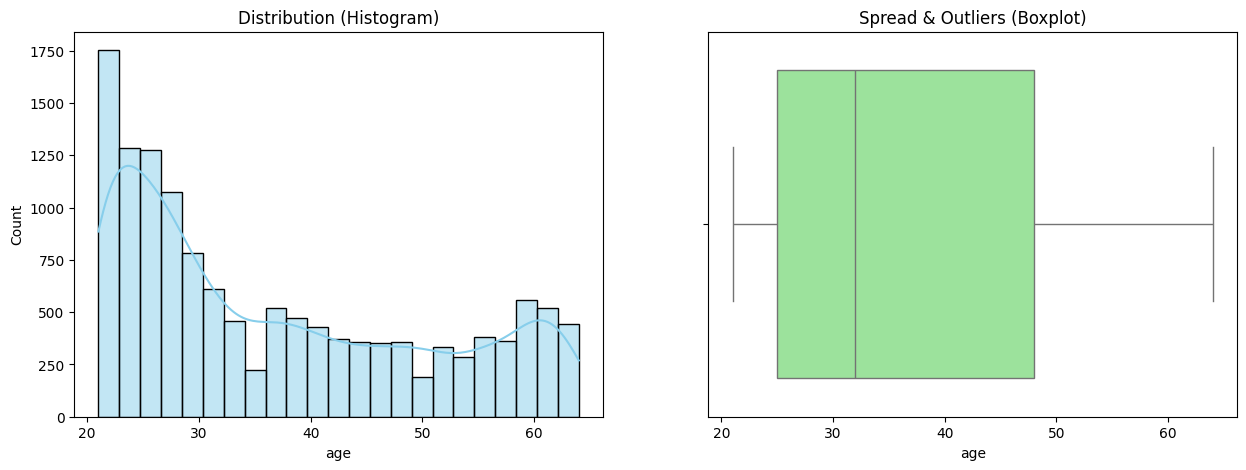

🔍 INSIGHTS & ACTIONS:
   ✅ No statistical outliers detected via IQR method.
Univariate Analysis: height_cm 
Mean: 168.56067054958183 | Median: 169.2 | Std: 8.42630502194104
Skewness: -0.18702929884607383 (Target: 0) 


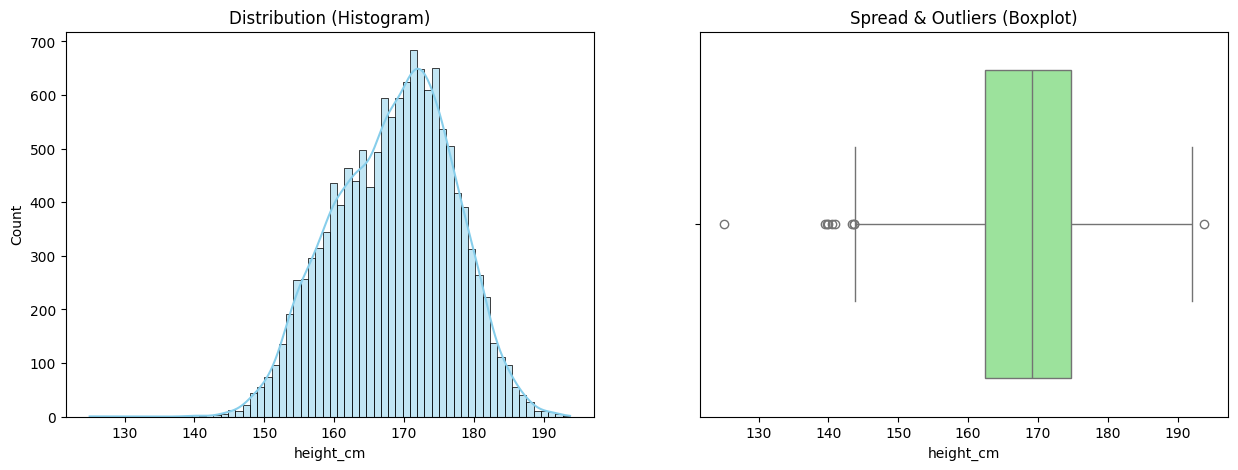

🔍 INSIGHTS & ACTIONS:
   ⚠️ Found 10 Outliers (Values < 143.80 or > 193.40).
      -> ACTION (If Error): Remove rows (e.g., negative Age).
      -> ACTION (If Valid): Cap values at min/max thresholds.
Univariate Analysis: weight_kg 
Mean: 67.44868578255675 | Median: 67.4 | Std: 11.949060599786405
Skewness: 0.3498102825397265 (Target: 0) 


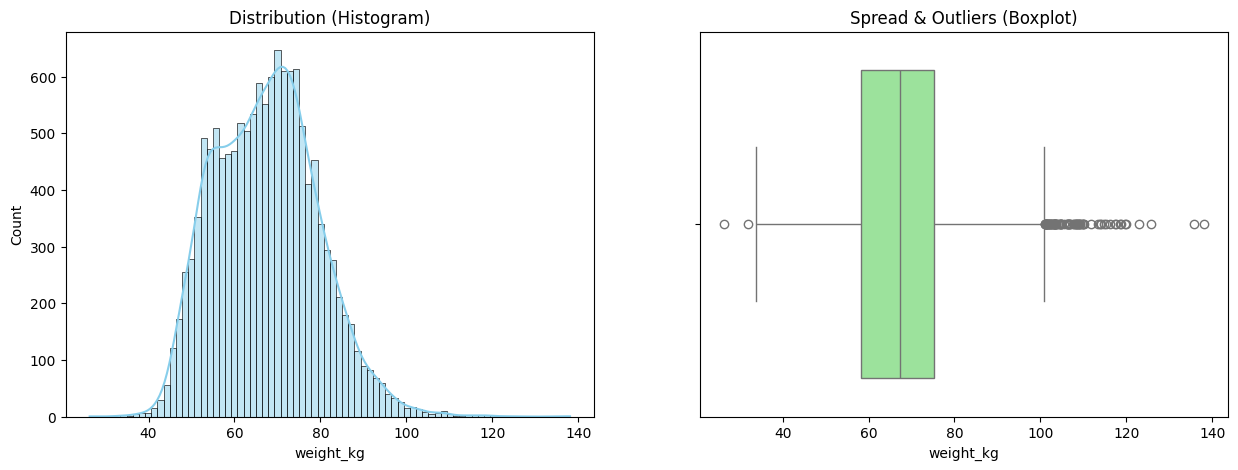

🔍 INSIGHTS & ACTIONS:
   ⚠️ Found 83 Outliers (Values < 32.55 or > 100.95).
      -> ACTION (If Error): Remove rows (e.g., negative Age).
      -> ACTION (If Valid): Cap values at min/max thresholds.
Univariate Analysis: body fat_% 
Mean: 23.239607914202505 | Median: 22.8 | Std: 7.256828687758748
Skewness: 0.36131070181674896 (Target: 0) 


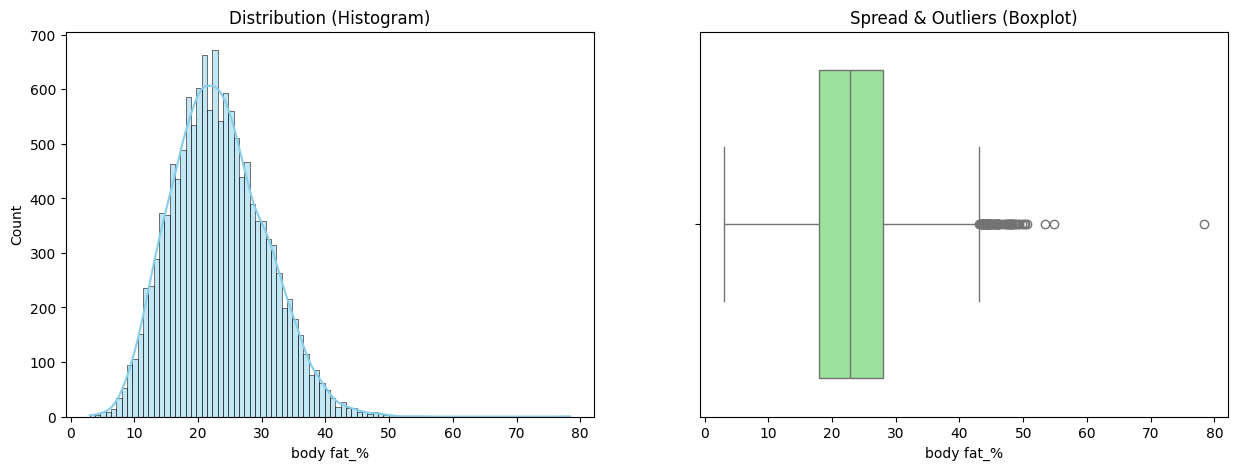

🔍 INSIGHTS & ACTIONS:
   ⚠️ Found 77 Outliers (Values < 3.00 or > 43.00).
      -> ACTION (If Error): Remove rows (e.g., negative Age).
      -> ACTION (If Valid): Cap values at min/max thresholds.
Univariate Analysis: diastolic 
Mean: 78.79749850657109 | Median: 79.0 | Std: 10.742165188014484
Skewness: -0.1597856629559943 (Target: 0) 


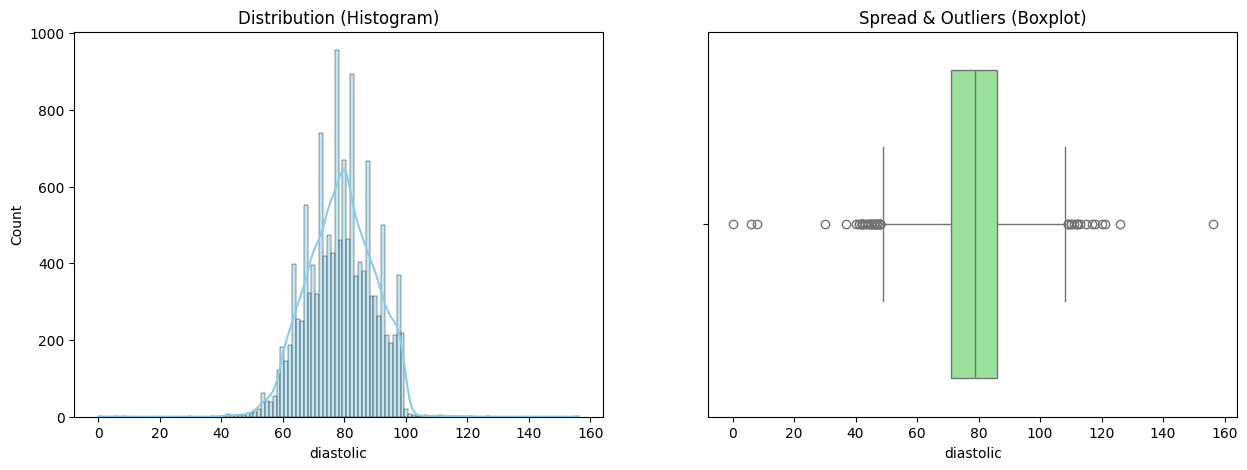

🔍 INSIGHTS & ACTIONS:
   ⚠️ Found 54 Outliers (Values < 48.50 or > 108.50).
      -> ACTION (If Error): Remove rows (e.g., negative Age).
      -> ACTION (If Valid): Cap values at min/max thresholds.
Univariate Analysis: systolic 
Mean: 130.2381197729988 | Median: 130.0 | Std: 14.709536464034938
Skewness: -0.047343674711883166 (Target: 0) 


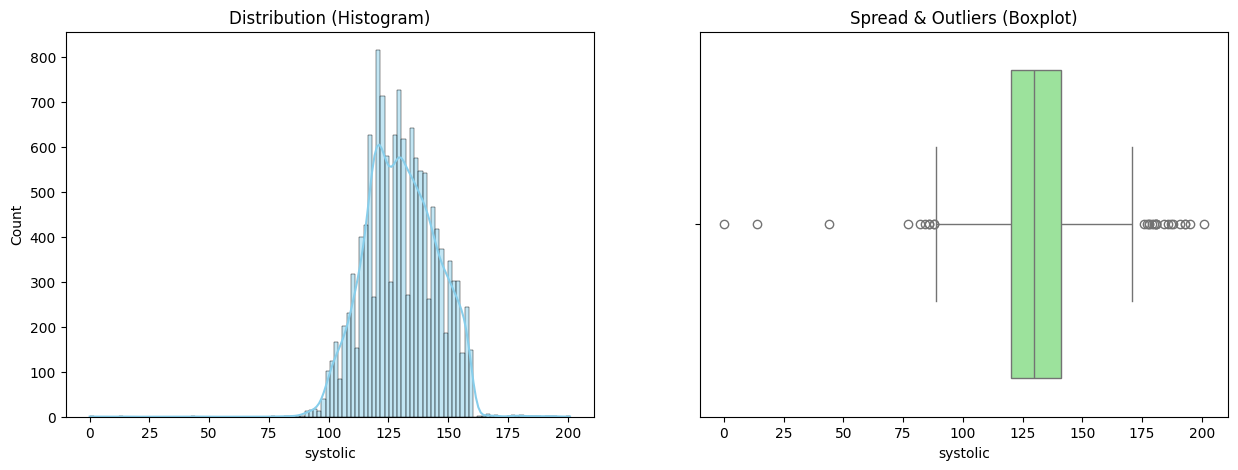

🔍 INSIGHTS & ACTIONS:
   ⚠️ Found 28 Outliers (Values < 88.50 or > 172.50).
      -> ACTION (If Error): Remove rows (e.g., negative Age).
      -> ACTION (If Valid): Cap values at min/max thresholds.
Univariate Analysis: gripForce 
Mean: 36.96456914575866 | Median: 37.9 | Std: 10.624959129412126
Skewness: 0.01831153439707532 (Target: 0) 


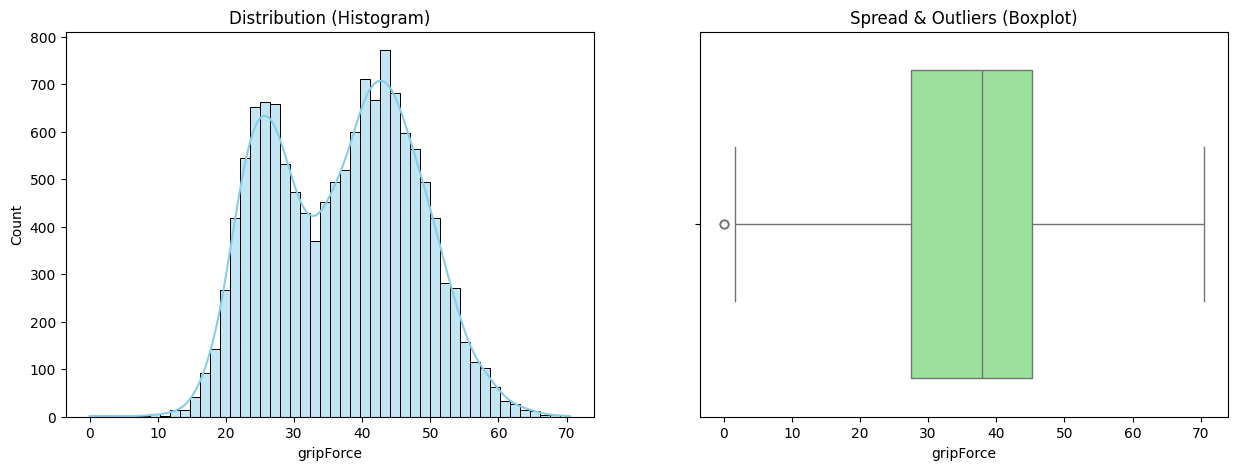

🔍 INSIGHTS & ACTIONS:
   ⚠️ Found 3 Outliers (Values < 0.95 or > 71.75).
      -> ACTION (If Error): Remove rows (e.g., negative Age).
      -> ACTION (If Valid): Cap values at min/max thresholds.
Univariate Analysis: sit and bend forward_cm 
Mean: 15.208932945041816 | Median: 16.2 | Std: 8.456903717983428
Skewness: 0.7855952903090583 (Target: 0) 


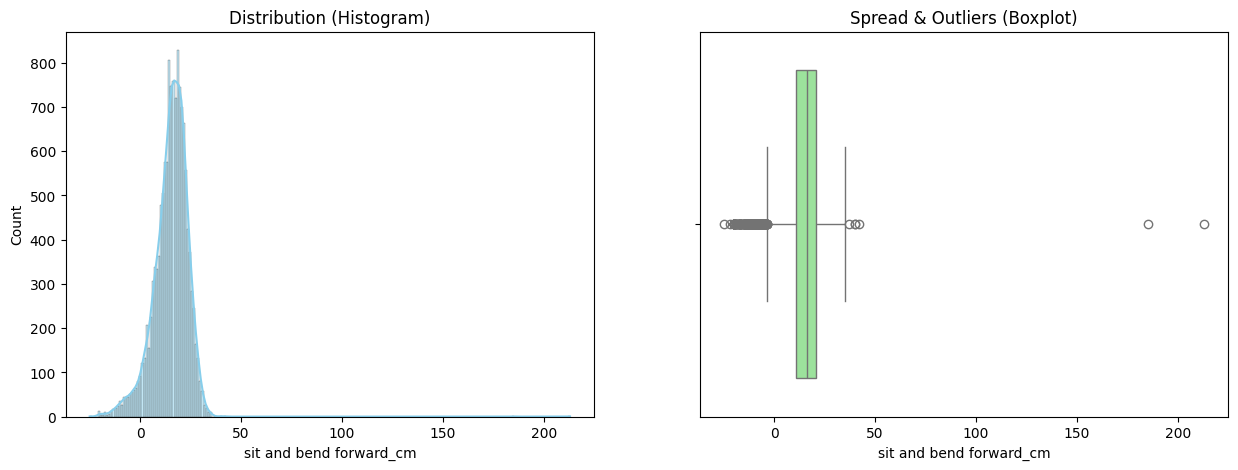

🔍 INSIGHTS & ACTIONS:
   ⚠️ Found 409 Outliers (Values < -3.80 or > 35.40).
      -> ACTION (If Error): Remove rows (e.g., negative Age).
      -> ACTION (If Valid): Cap values at min/max thresholds.
Univariate Analysis: sit-ups counts 
Mean: 39.7703853046595 | Median: 41.0 | Std: 14.27690161443124
Skewness: -0.46770495662546807 (Target: 0) 


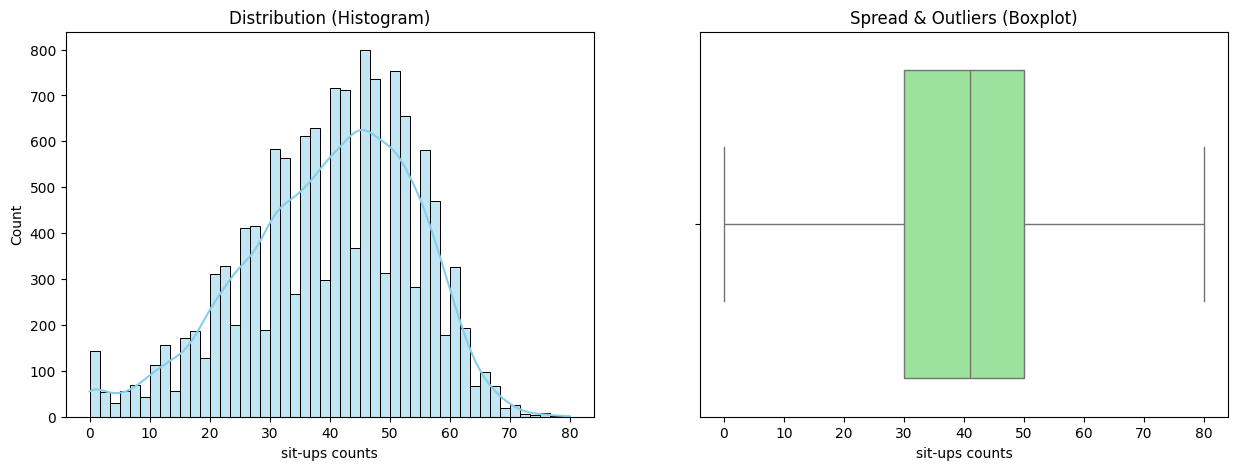

🔍 INSIGHTS & ACTIONS:
   ✅ No statistical outliers detected via IQR method.
Univariate Analysis: broad jump_cm 
Mean: 190.1313545400239 | Median: 193.0 | Std: 39.868987657730436
Skewness: -0.42273811129113775 (Target: 0) 


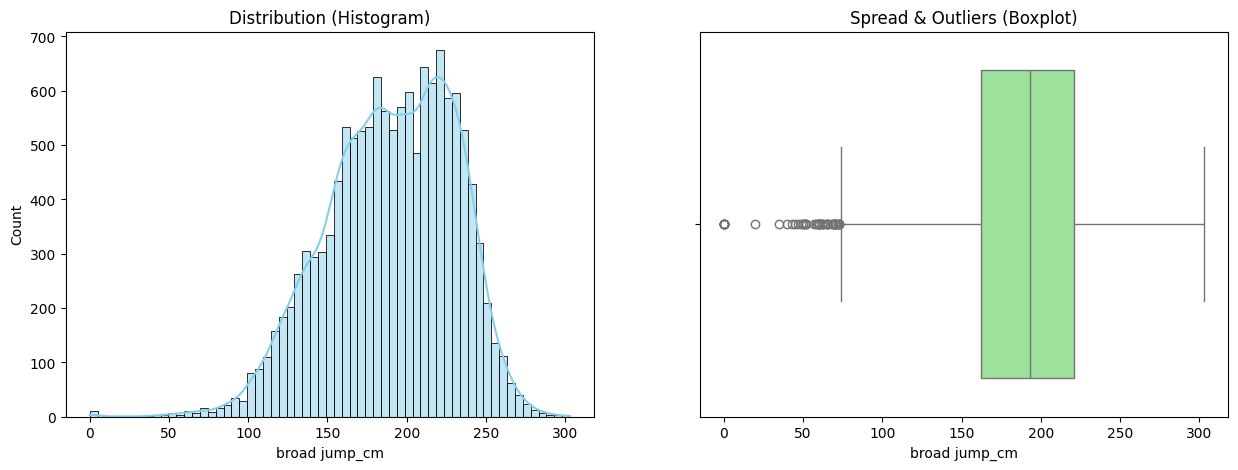

🔍 INSIGHTS & ACTIONS:
   ⚠️ Found 57 Outliers (Values < 73.50 or > 309.50).
      -> ACTION (If Error): Remove rows (e.g., negative Age).
      -> ACTION (If Valid): Cap values at min/max thresholds.


In [12]:
def analyze_numerical_variable(df, column):
    print(f"Univariate Analysis: {column} ")
    
    # 1. Non-Graphical Stats
    desc = df[column].describe()
    skew = df[column].skew()
    
    print(f"Mean: {desc['mean']} | Median: {desc['50%']:} | Std: {desc['std']:}")
    print(f"Skewness: {skew} (Target: 0) ")
    
    # 2. Visualizations (Histogram, Boxplot, Q-Q Plot)
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Histogram with KDE (Density)
    sns.histplot(df[column].dropna(), kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f'Distribution (Histogram)')
    
    # Boxplot (Outlier Detection)
    sns.boxplot(x=df[column], ax=axes[1], color='lightgreen')
    axes[1].set_title(f'Spread & Outliers (Boxplot)')
    
    
    plt.show()
    
    # 3. Automated Insights & Actions
    print("🔍 INSIGHTS & ACTIONS:")
    
    # Skewness check
    if abs(skew) > 1:
        print(f"   ⚠️ High Skewness ({skew:.2f}).")
        print("      -> ACTION: Consider Log Transformation (np.log1p) or Square Root transformation.")
    
    # Outlier check (IQR Method)
    Q1 = desc['25%']
    Q3 = desc['75%']
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower) | (df[column] > upper)]
    
    if len(outliers) > 0:
        print(f"   ⚠️ Found {len(outliers)} Outliers (Values < {lower:.2f} or > {upper:.2f}).")
        print("      -> ACTION (If Error): Remove rows (e.g., negative Age).")
        print("      -> ACTION (If Valid): Cap values at min/max thresholds.")
    else:
        print("   ✅ No statistical outliers detected via IQR method.")

# Execution for numerical columns
num_cols = df2.select_dtypes(include=[np.number]).columns.tolist()
for col in num_cols:
    analyze_numerical_variable(df2, col)

## 4. Univariate Analysis: Categorical

**Theory:**
For categorical data, concepts like Mean/Std Dev don't exist.  We focus on **Frequency** and **Relative Frequency (Proportion)**.

### Interpretation & Actions Checklist:
1.  **Dominant Class (Low Variance):**
    * *Observation:* 99% of data is "Category A".
    * *Action:* Drop the feature. It provides no information for the model to learn differences.
2.  **Inconsistent Labeling (Pattern Violation):**
    * *Observation:* "NY", "ny", "New York".
    * *Action:* Standardize strings (lowercase, strip whitespace).


--- 📊 Univariate Analysis: gender ---


C:\Users\muham\AppData\Local\Temp\ipykernel_15512\3447202971.py:32: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df2.select_dtypes(include=['object', 'category']).columns.tolist()


,Count,Percentage
gender,,
M,8467,63.224313
F,4925,36.775687


C:\Users\muham\AppData\Local\Temp\ipykernel_15512\3447202971.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[column], order=counts.index, palette='viridis')


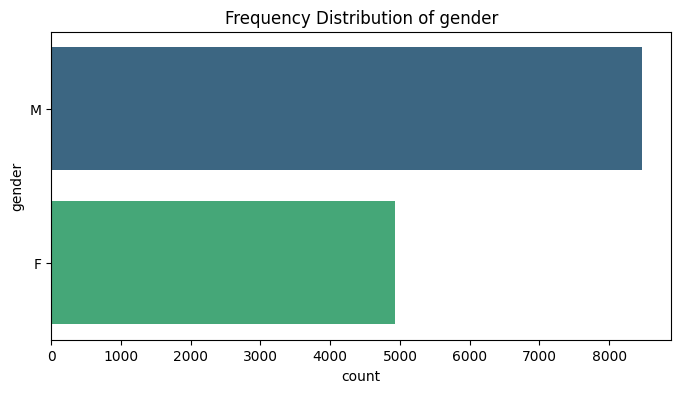

🔍 INSIGHTS & ACTIONS:

--- 📊 Univariate Analysis: class ---


,Count,Percentage
class,,
C,3349,25.007467
D,3349,25.007467
A,3347,24.992533
B,3347,24.992533


C:\Users\muham\AppData\Local\Temp\ipykernel_15512\3447202971.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[column], order=counts.index, palette='viridis')


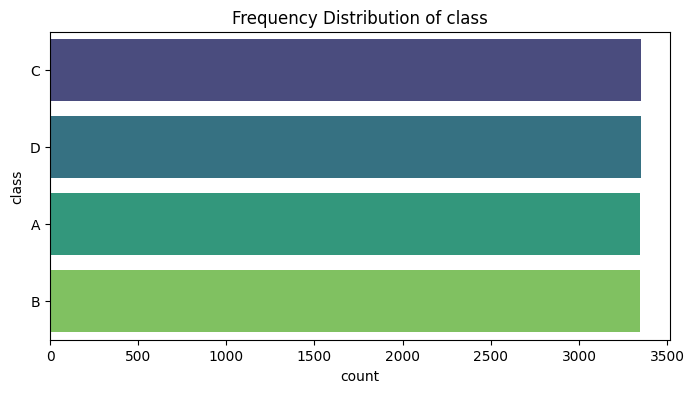

🔍 INSIGHTS & ACTIONS:


In [13]:
def analyze_categorical_variable(df, column):
    print(f"\n--- 📊 Univariate Analysis: {column} ---")
    
    # 1. Non-Graphical Stats
    counts = df[column].value_counts()
    props = df[column].value_counts(normalize=True) * 100
    
    # Combine into a dataframe for display
    summary = pd.DataFrame({'Count': counts, 'Percentage': props})
    display(summary)
    
    # 2. Visualization (Bar Plot)
    plt.figure(figsize=(8, 4))
    sns.countplot(y=df[column], order=counts.index, palette='viridis')
    plt.title(f'Frequency Distribution of {column}')
    plt.show()
    
    # 3. Automated Insights & Actions
    print("🔍 INSIGHTS & ACTIONS:")
          
    # Check for Dominant Class
    if props.iloc[0] > 95:
        print(f"   ⚠️ Dominated Feature: '{counts.index[0]}' is {props.iloc[0]:.2f}% of data.")
        print("      -> ACTION: Consider dropping this column (insufficient variance).")
        
    # Check for Dirty Data (Example logic)
    # Checking if multiple indices look similar (e.g., 'NY' and 'ny')
    if df[column].dtype == 'object':
        print("      -> NOTE: Check for mixed case labels (e.g., 'Male' vs 'male') and standardize.")

# Execution for categorical columns
cat_cols = df2.select_dtypes(include=['object', 'category']).columns.tolist()

for col in cat_cols:
    if df2[col].nunique() < 30:
        analyze_categorical_variable(df2, col)
    elif df2[col].nunique() < 100 :
        # For high-cardinality columns, group non-top-20 values into 'Others'
        top_20 = df2[col].value_counts().index[:20]
        df_temp = df2[[col]].copy()
        df_temp[col] = df_temp[col].where(df_temp[col].isin(top_20), 'Others')
        analyze_categorical_variable(df_temp, col)
    else:
        continue

## 5. Multivariate Analysis: Relationships

**Theory:**
We investigate relationships between variables to select models and features.  This includes **Correlation** (Numerical vs Numerical) and **Conditioning** (Numerical vs Categorical).

### A. Numerical vs. Numerical (Correlation)
**Logic:**
* **Correlation = +1/-1:** Perfect linear relationship.
* **Correlation = 0:** No *linear* relationship (could still be non-linear).
**Actions:**
* **High Multicollinearity (r > 0.9):** Two variables move exactly together.
    * *Action:* Drop one of them. They provide redundant info to the model.

### B. Numerical vs. Categorical (Conditioning)
**Logic:**
* Compare the distribution of the number across categories.
**Actions:**
* **Different Medians/Ranges:** The category suggests the number.
    * *Action:* This is a good predictor (feature) for ML models.

### C. Categorical vs. Categorical 


Available Numerical Columns for selection:
1: age
2: height_cm
3: weight_kg
4: body fat_%
5: diastolic
6: systolic
7: gripForce
8: sit and bend forward_cm
9: sit-ups counts
10: broad jump_cm


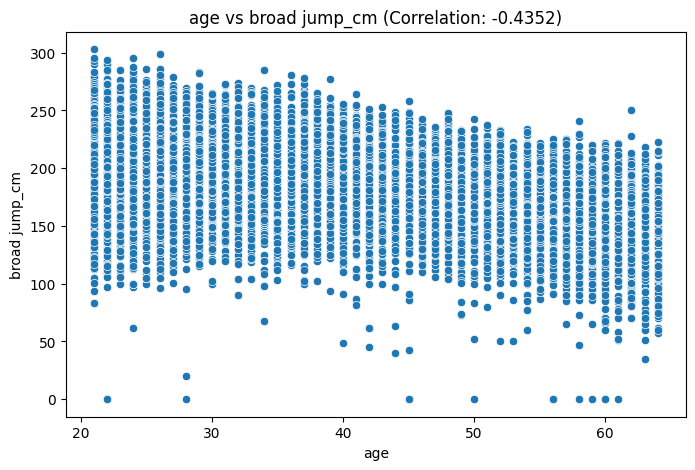

Analysis for age:
- Correlation Score: -0.4352
- Interpretation: There is a moderate negative linear relationship.
------------------------------


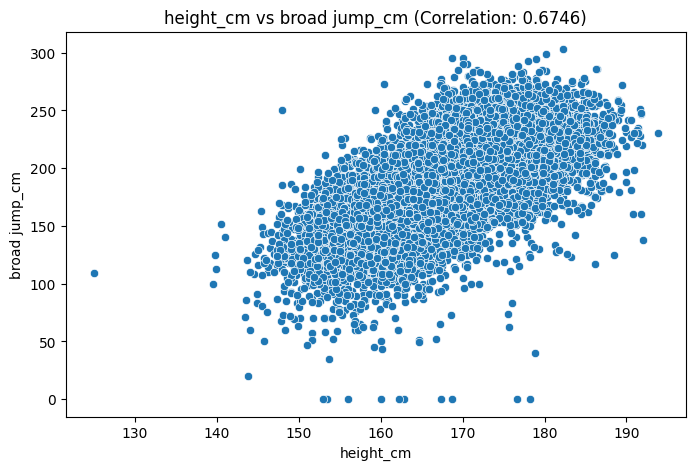

Analysis for height_cm:
- Correlation Score: 0.6746
- Interpretation: There is a moderate positive linear relationship.
------------------------------


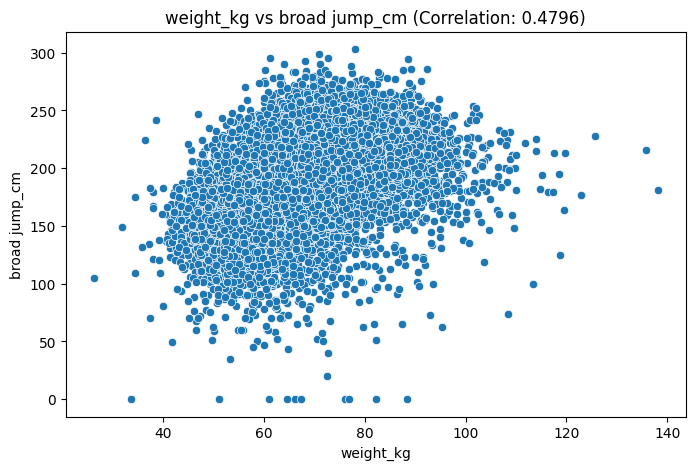

Analysis for weight_kg:
- Correlation Score: 0.4796
- Interpretation: There is a moderate positive linear relationship.
------------------------------


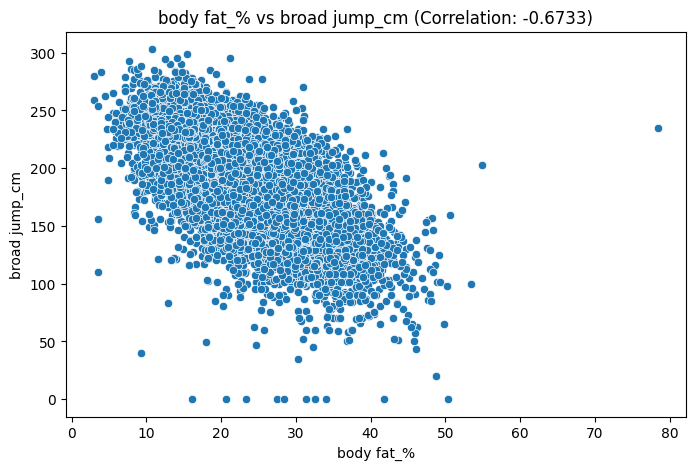

Analysis for body fat_%:
- Correlation Score: -0.6733
- Interpretation: There is a moderate negative linear relationship.
------------------------------


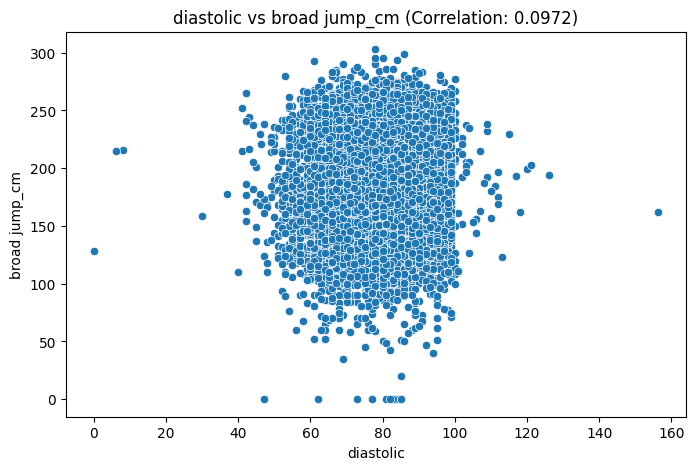

Analysis for diastolic:
- Correlation Score: 0.0972
- Interpretation: There is a weak positive linear relationship.
------------------------------


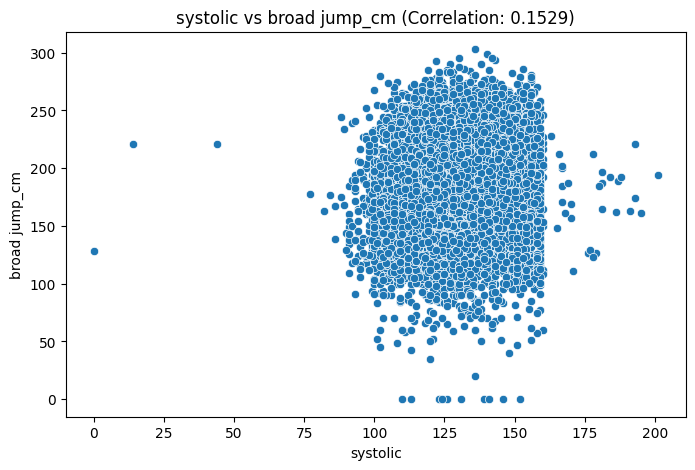

Analysis for systolic:
- Correlation Score: 0.1529
- Interpretation: There is a weak positive linear relationship.
------------------------------


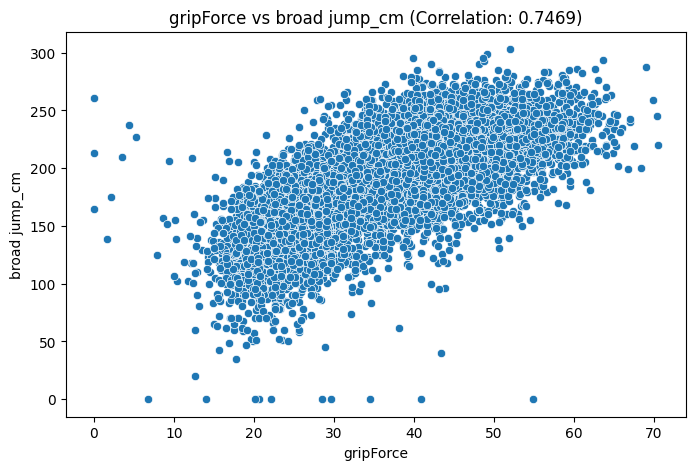

Analysis for gripForce:
- Correlation Score: 0.7469
- Interpretation: There is a strong positive linear relationship.
------------------------------


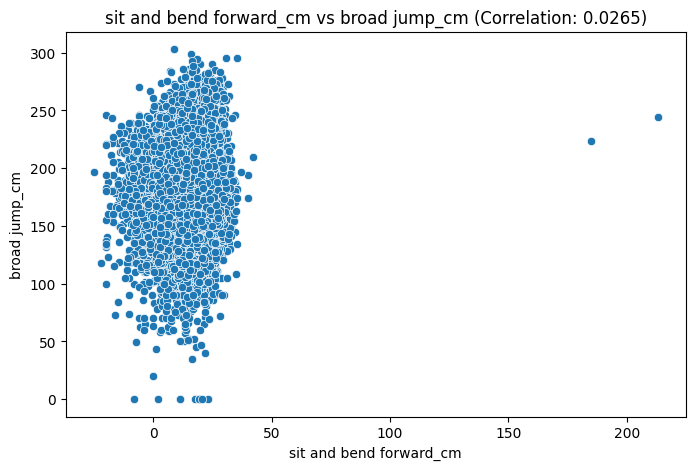

Analysis for sit and bend forward_cm:
- Correlation Score: 0.0265
- Interpretation: There is a weak positive linear relationship.
------------------------------


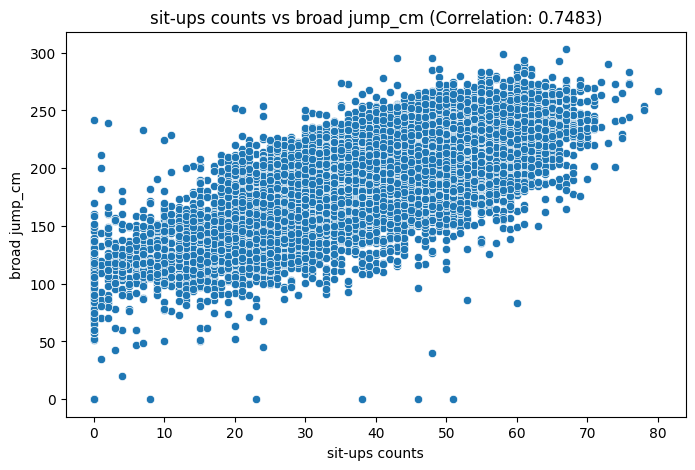

Analysis for sit-ups counts:
- Correlation Score: 0.7483
- Interpretation: There is a strong positive linear relationship.
------------------------------

Features ranked by influence (absolute correlation) on broad jump_cm:
sit-ups counts       | Correlation:   0.7483
gripForce            | Correlation:   0.7469
height_cm            | Correlation:   0.6746
body fat_%           | Correlation:  -0.6733
weight_kg            | Correlation:   0.4796
age                  | Correlation:  -0.4352
systolic             | Correlation:   0.1529
diastolic            | Correlation:   0.0972
sit and bend forward_cm | Correlation:   0.0265


In [17]:
# Identify numerical columns
num_cols = df.select_dtypes(include=['number']).columns.tolist()

print("\nAvailable Numerical Columns for selection:")
for i, col in enumerate(num_cols):
    print(f"{i+1}: {col}")

target_index = int(input("Please insert target column index: "))
target = num_cols[target_index - 1]
correlations = {}



for i, col in enumerate(num_cols):
    if i == target_index - 1:
        continue
        
    # Calculate Correlation
    corr_val = df[col].corr(df[target])
    correlations[col] = corr_val
    
    # Plotting

    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df, x=col, y=target)
    plt.title(f"{col} vs {target} (Correlation: {corr_val:.4f})")
    plt.show()

    
    # Analytics interpretation
    strength = "Strong" if abs(corr_val) > 0.7 else "Moderate" if abs(corr_val) > 0.3 else "Weak"
    direction = "Positive" if corr_val > 0 else "Negative"
    print(f"Analysis for {col}:")
    print(f"- Correlation Score: {corr_val:.4f}")
    print(f"- Interpretation: There is a {strength.lower()} {direction.lower()} linear relationship.")
    print("-" * 30)

# Print final sorted correlations
print("\nFeatures ranked by influence (absolute correlation) on " + target + ":")
sorted_corr = sorted(correlations.items(), key=lambda x: abs(x[1]), reverse=True)
for col, val in sorted_corr:
    print(f"{col:20} | Correlation: {val:>8.4f}")



--- 🔗 Multivariate Analysis ---

Available Numerical Columns for selection:
1: age
2: height_cm
3: weight_kg
4: body fat_%
5: diastolic
6: systolic
7: gripForce
8: sit and bend forward_cm
9: sit-ups counts
10: broad jump_cm


C:\Users\muham\AppData\Local\Temp\ipykernel_15512\615789525.py:50: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df2.select_dtypes(include=['object', 'category']).columns.tolist()
C:\Users\muham\AppData\Local\Temp\ipykernel_15512\615789525.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=cat, y=target_num, data=df2, palette='Set2')


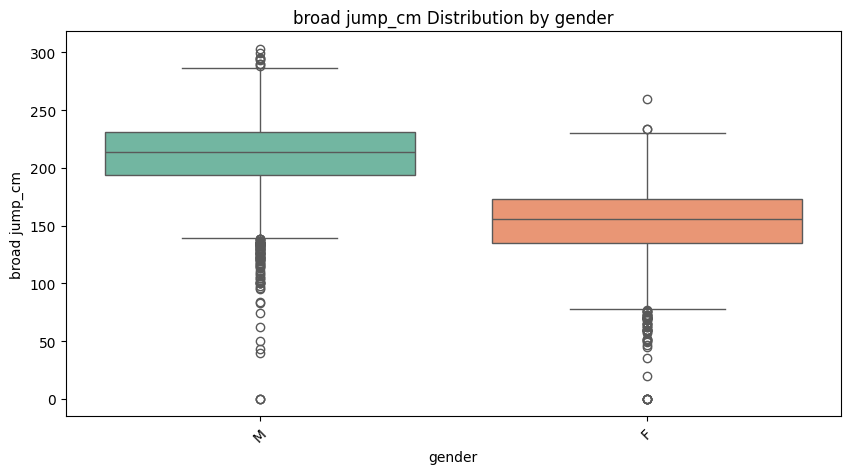

   ℹ️ interpreting: Do the box positions change significantly between gender groups?
      -> IF YES: gender is likely a good predictor for broad jump_cm.


C:\Users\muham\AppData\Local\Temp\ipykernel_15512\615789525.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=cat, y=target_num, data=df2, palette='Set2')


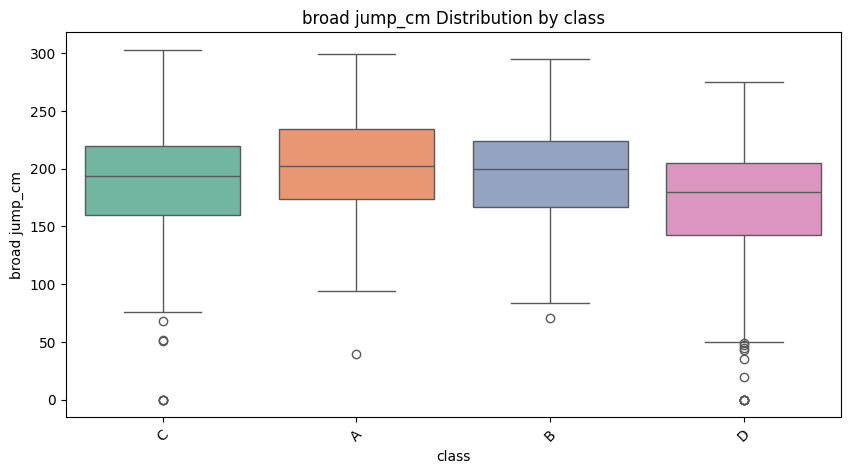

   ℹ️ interpreting: Do the box positions change significantly between class groups?
      -> IF YES: class is likely a good predictor for broad jump_cm.


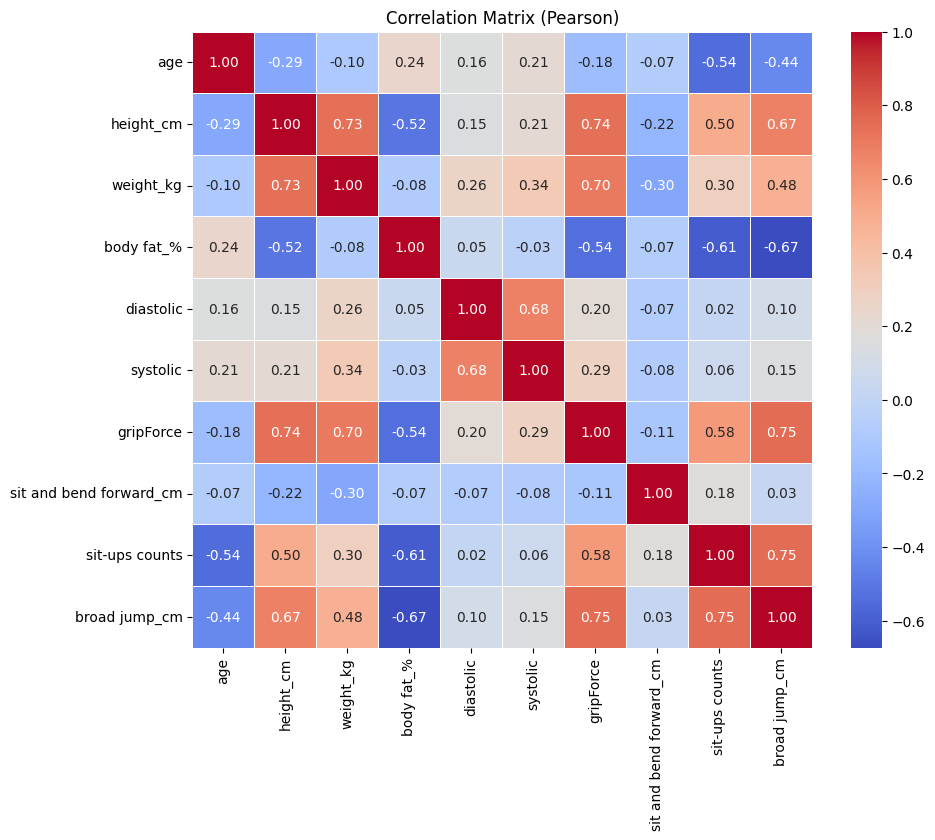

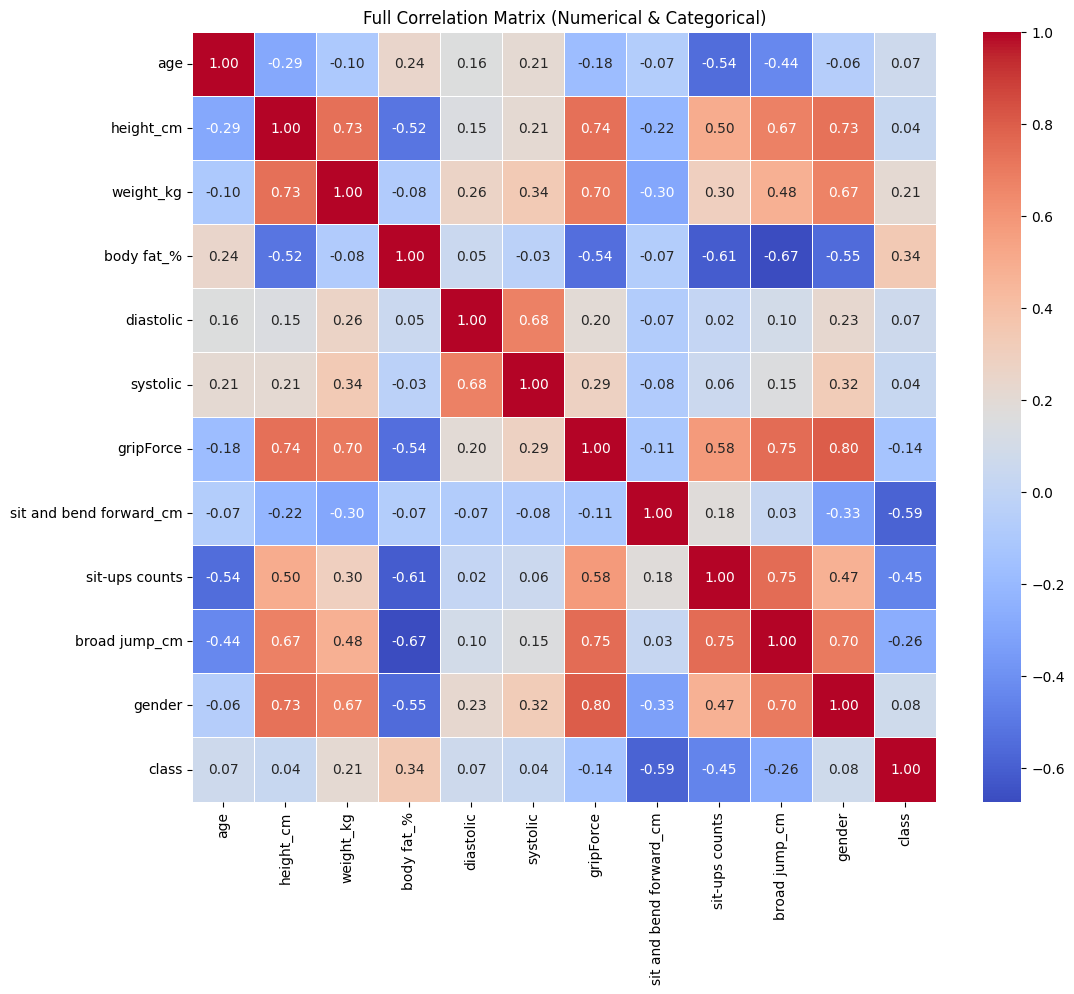


--- Correlations with Target: broad jump_cm ---
broad jump_cm              1.000000
sit-ups counts             0.748334
gripForce                  0.746846
gender                     0.704146
height_cm                  0.674586
body fat_%                -0.673264
weight_kg                  0.479546
age                       -0.435217
class                     -0.262233
systolic                   0.152817
diastolic                  0.097211
sit and bend forward_cm    0.026511
Name: broad jump_cm, dtype: float64


In [19]:
def analyze_multivariate(df, num_cols, cat_cols):
    print("\n--- 🔗 Multivariate Analysis ---")
    
    # 1. Numerical vs Categorical (Side-by-Side Boxplots)
    # Compare the first Numerical variable against all Categorical variables
    if len(num_cols) > 0 and len(cat_cols) > 0:

        print("\nAvailable Numerical Columns for selection:")
        for i, col in enumerate(num_cols):
            print(f"{i+1}: {col}")

        Target_index = int(input("Please insert target column index"))
        
        target_num = num_cols[Target_index-1] # Taking the first one as example (e.g., 'Age')
        
        for cat in cat_cols:
            plt.figure(figsize=(10, 5))
            sns.boxplot(x=cat, y=target_num, data=df2, palette='Set2')
            plt.title(f'{target_num} Distribution by {cat}')
            plt.xticks(rotation=45)
            plt.show()
            print(f"   ℹ️ interpreting: Do the box positions change significantly between {cat} groups?")
            print(f"      -> IF YES: {cat} is likely a good predictor for {target_num}.")
    
     # 2. Numerical Correlation Matrix
    if len(num_cols) > 1:
        corr = df2[num_cols].corr()
        
        plt.figure(figsize=(10, 8))
        sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
        plt.title("Correlation Matrix (Pearson)")

        # Correlation Matrix for All Columns (Numerical + Categorical)
        df_encoded = df2[num_cols + cat_cols].copy()
        for col in cat_cols:
            df_encoded[col] = df_encoded[col].astype('category').cat.codes
            
        plt.figure(figsize=(12, 10))
        sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
        plt.title("Full Correlation Matrix (Numerical & Categorical)")
        plt.show()

    print(f"\n--- Correlations with Target: {target_num} ---")
    target_corr = df_encoded.corr()[target_num].sort_values(key=abs, ascending=False)
    print(target_corr)

# Execution
num_cols = df2.select_dtypes(include=[np.number]).columns.tolist()

cat_cols = df2.select_dtypes(include=['object', 'category']).columns.tolist()


cat_cols_filtered = [col for col in cat_cols if df2[col].nunique() < 20]
analyze_multivariate(df2, num_cols, cat_cols_filtered)



## 6. Final Summary & Data Transformation Plan

Based on the analysis above, your next steps (Data Transformation) should be:

1.  **Imputation:** You decided how to fill missing values (Mean/Median/Mode).
2.  **Outlier Handling:** You decided to Drop or Cap outliers.
3.  **Feature Engineering:** 
    * If Skewed -> Apply Log Transform.
    * If Categorical -> Apply One-Hot or Label Encoding.
4.  **Scaling:**
    * Use **Min-Max** if you need fixed range.
    * Use **Z-Score (Standardization)** for algorithms assuming normality (linear regression, neural nets).

This concludes the Exploratory Data Analysis.